1.  Como o desempenho varia por faixa etária?
2. Qual é a distribuição de idade dos participantes? (histograma)
3. Proporção de cor/raça? (grafico de pizza)
4. O grau de ocupação do pai e a media de nota
5. O grau de ocupação da mae e a media da nota
7. O grau de ensino dos pais tem impacto, qual tem o maior impacto, da mãe ou do pai
8. Qual a média de renda per capta baseado na Cor ou raça, a nota média é impactada por esses fatores

In [2]:
import sys
!{sys.executable} -m pip install seaborn

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('dados_ceara.csv')
df

,Número de Inscrição,Ano do Enem,Faixa Etária,Sexo,Estado Civil,Cor/Raça,Nacionalidade,Situação de Conclusão do Ensino Médio,Ano de Conclusão do Ensino Médio,Tipo de Escola do Ensino Médio,...,Forno Micro-ondas na Residência,Máquina de Lavar Louça na Residência,Aspirador de Pó na Residência,Televisão em Cores na Residência,Aparelho de DVD na Residência,TV por Assinatura na Residência,Telefone Celular na Residência,Telefone Fixo na Residência,Computador na Residência,Acesso à Internet na Residência
0,210060214087,2023,17 anos,F,Solteiro(a),Parda,Brasileiro(a),Estou cursando e concluirei em 2023,Não informado,Pública,...,Não,Não,Não,"Sim, uma",Não,Não,"Sim, três",Não,Não,Sim
1,210059980948,2023,18 anos,F,Solteiro(a),Parda,Brasileiro(a),Estou cursando e concluirei em 2023,Não informado,Pública,...,Não,Não,Não,"Sim, uma",Não,Não,"Sim, um",Não,Não,Não
2,210059980944,2023,24 anos,F,Solteiro(a),Preta,Brasileiro(a),Já concluí o Ensino Médio,2016,Não Respondeu,...,Não,Não,Não,"Sim, uma",Não,Não,"Sim, três",Não,Não,Não
3,210059388091,2023,20 anos,F,Solteiro(a),Parda,Brasileiro(a),Já concluí o Ensino Médio,2020,Não Respondeu,...,Não,Não,Não,"Sim, uma",Não,Não,"Sim, três",Não,"Sim, um",Sim
4,210059388092,2023,18 anos,F,Solteiro(a),Parda,Brasileiro(a),Estou cursando e concluirei em 2023,Não informado,Pública,...,Não,Não,Não,"Sim, uma",Não,Não,"Sim, um",Não,Não,Sim
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241955,210059503194,2023,Entre 26 e 30 anos,M,Não informado,Parda,Brasileiro(a),Já concluí o Ensino Médio,2013,Não Respondeu,...,Não,Não,Não,"Sim, uma",Não,Não,"Sim, dois",Não,"Sim, um",Sim
241956,210059181672,2023,23 anos,M,Solteiro(a),Branca,Brasileiro(a),Já concluí o Ensino Médio,2017,Não Respondeu,...,Não,Não,Não,"Sim, uma",Não,Sim,"Sim, dois",Não,Não,Sim
241957,210060277719,2023,Menor de 17 anos,M,Solteiro(a),Branca,Brasileiro(a),Estou cursando e concluirei após 2023,Não informado,Não Respondeu,...,Não,Não,Sim,"Sim, três",Não,Não,"Sim, três",Não,"Sim, dois",Sim
241958,210060897061,2023,Entre 26 e 30 anos,M,Solteiro(a),Amarela,Brasileiro(a),Já concluí o Ensino Médio,Não informado,Não Respondeu,...,Não,Não,Não,"Sim, uma",Não,Não,"Sim, dois",Não,Não,Sim


In [4]:
colunas_notas = [
    'Nota Ciências da Natureza', 
    'Nota Ciências Humanas',
    'Nota Linguagens e Códigos', 
    'Nota Matemática',
    'Nota Redação'
]
df['nota_media'] =(df['Nota Ciências da Natureza'] + df['Nota Ciências Humanas'] + df['Nota Linguagens e Códigos'] + df['Nota Matemática'] + df['Nota Redação'])/5
df['nota_media'].describe()

count    173700.000000
mean        528.932128
std         102.928557
min           0.000000
25%         459.200000
50%         529.800000
75%         600.460000
max         836.700000
Name: nota_media, dtype: float64

In [5]:
df['Media_Geral'] = df[colunas_notas].mean(axis=1)

1. Faixa Etária e a Media

In [6]:
# Ver valores únicos na coluna
print(df['Faixa Etária'].unique())
print("\nContagem de participantes por faixa etária:")
print(df['Faixa Etária'].value_counts())

<StringArray>
[           '17 anos',            '18 anos',            '24 anos',
            '20 anos', 'Entre 26 e 30 anos',            '22 anos',
            '23 anos', 'Entre 31 e 35 anos',            '19 anos',
            '21 anos',            '25 anos',   'Menor de 17 anos',
 'Entre 51 e 55 anos', 'Entre 41 e 45 anos', 'Entre 36 e 40 anos',
 'Entre 46 e 50 anos', 'Entre 56 e 60 anos', 'Entre 61 e 65 anos',
 'Entre 66 e 70 anos',   'Maior de 70 anos']
Length: 20, dtype: str

Contagem de participantes por faixa etária:
Faixa Etária
18 anos               64975
17 anos               52271
19 anos               25819
Menor de 17 anos      23849
20 anos               14477
Entre 26 e 30 anos    12611
21 anos                9475
Entre 31 e 35 anos     6763
22 anos                6740
23 anos                5398
Entre 36 e 40 anos     4819
24 anos                4371
25 anos                3462
Entre 41 e 45 anos     3030
Entre 46 e 50 anos     1816
Entre 51 e 55 anos     1084
Entre 56 e

In [7]:
# Criar coluna de faixa etária consolidada
def consolidar_faixa(x):
    if not isinstance(x, str):
        return x
    
    # Extrai o primeiro número da string
    numeros = [int(s) for s in x.split() if s.isdigit()]
    
    if not numeros:
        return x
    
    idade = numeros[0]
    
    # Consolidar por faixa
    if idade < 17:
        return 'Menor de 17 anos'
    elif idade >= 26 and idade <= 30:
        return '26+'
    elif idade >= 31 and idade <= 35:
        return '31+'
    elif idade >= 36:
        return '40+'
    
    return x

df['Faixa Etária Consolidada'] = df['Faixa Etária'].apply(consolidar_faixa)

print("Nova distribuição com faixas consolidadas:")
print(df['Faixa Etária Consolidada'].value_counts())

Nova distribuição com faixas consolidadas:
Faixa Etária Consolidada
18 anos             64975
17 anos             52271
19 anos             25819
Menor de 17 anos    23849
20 anos             14477
26+                 12611
40+                 11749
21 anos              9475
31+                  6763
22 anos              6740
23 anos              5398
24 anos              4371
25 anos              3462
Name: count, dtype: int64


In [8]:
df_agrupado = df.groupby('Faixa Etária Consolidada')['Media_Geral'].mean().reset_index()

# Definir ordem customizada
ordem = ['Menor de 17 anos', '17 anos', '18 anos', '19 anos', '20 anos', 
         '21 anos', '22 anos', '23 anos', '24 anos', '25 anos', '26+', '31+', '40+']

df_agrupado['Faixa Etária Consolidada'] = pd.Categorical(df_agrupado['Faixa Etária Consolidada'], 
                                                           categories=ordem,
                                                           ordered=True)
df_agrupado = df_agrupado.sort_values('Faixa Etária Consolidada')

C:\Users\pvito\AppData\Local\Temp\ipykernel_22020\3623040315.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_agrupado, x='Faixa Etária Consolidada', y='Media_Geral', palette='viridis')


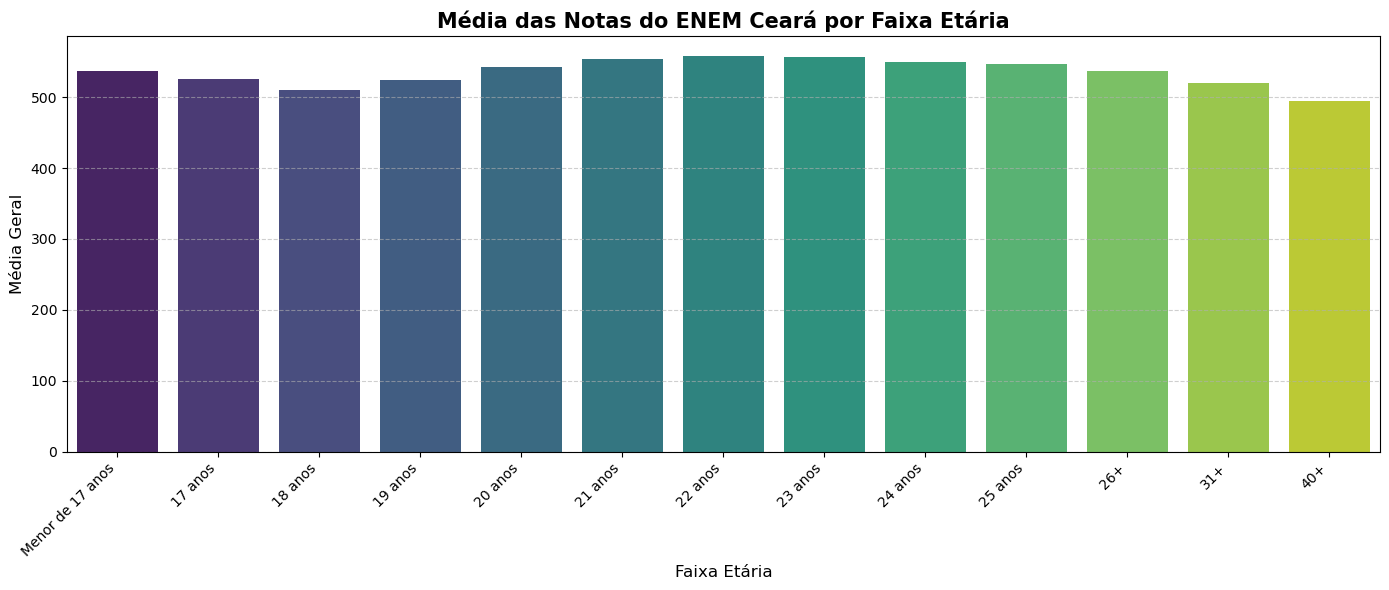

In [9]:
plt.figure(figsize=(14, 6))
sns.barplot(data=df_agrupado, x='Faixa Etária Consolidada', y='Media_Geral', palette='viridis')

plt.title('Média das Notas do ENEM Ceará por Faixa Etária', fontsize=15, fontweight='bold')
plt.xlabel('Faixa Etária', fontsize=12)
plt.ylabel('Média Geral', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

2. Qual é a distribuição de idade dos participantes? (histograma)

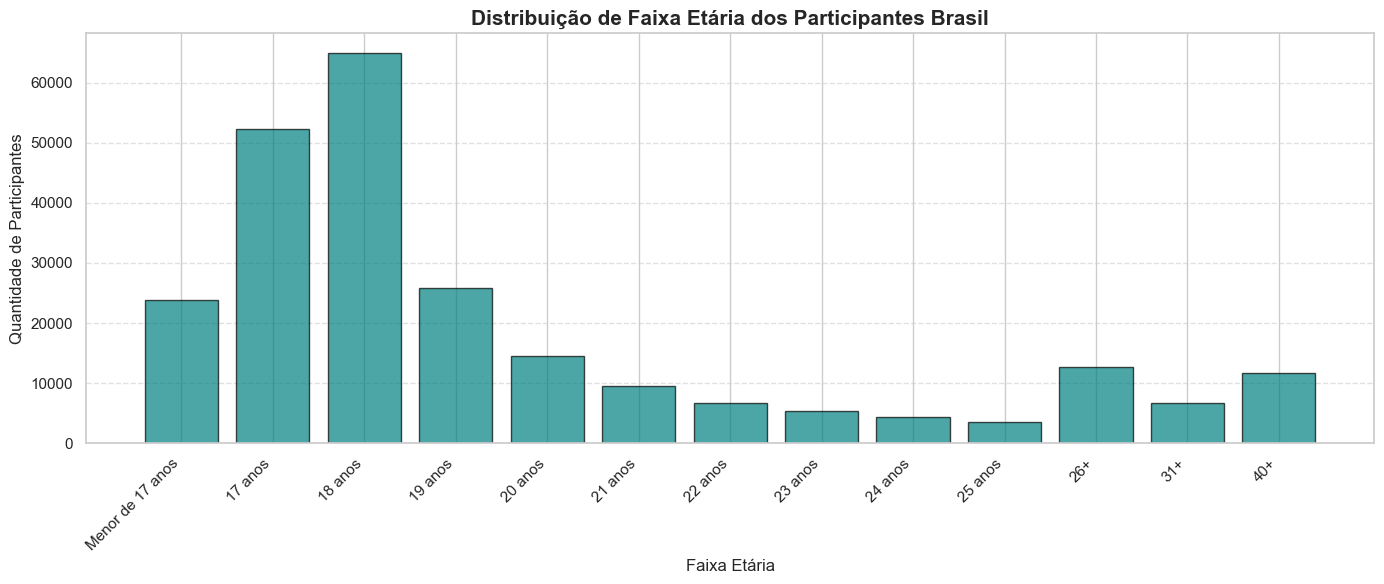

Distribuição por faixa etária (ordenada):
Faixa Etária Consolidada
Menor de 17 anos    23849
17 anos             52271
18 anos             64975
19 anos             25819
20 anos             14477
21 anos              9475
22 anos              6740
23 anos              5398
24 anos              4371
25 anos              3462
26+                 12611
31+                  6763
40+                 11749
Name: count, dtype: int64


In [10]:
import re

# Extrair a primeira idade do intervalo (se ainda não foi feito)
def extrair_idade(x):
    if not isinstance(x, str):
        return None
    
    numeros = re.findall(r'\d+', x)
    
    if numeros:
        return int(numeros[0])
    return None

df['Idade'] = df['Faixa Etária'].apply(extrair_idade)

# Usar a coluna já criada 'Faixa Etária Consolidada'
ordem = ['Menor de 17 anos', '17 anos', '18 anos', '19 anos', '20 anos', 
         '21 anos', '22 anos', '23 anos', '24 anos', '25 anos', '26+', '31+', '40+']

# Contar por faixa
contagem = df['Faixa Etária Consolidada'].value_counts()
contagem_ordenada = contagem.reindex(ordem, fill_value=0)

# Criar gráfico de barras
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

plt.bar(range(len(contagem_ordenada)), contagem_ordenada.values, color='teal', alpha=0.7, edgecolor='black')
plt.xticks(range(len(ordem)), ordem, rotation=45, ha='right')

plt.title('Distribuição de Faixa Etária dos Participantes Brasil', fontsize=15, fontweight='bold')
plt.xlabel('Faixa Etária', fontsize=12)
plt.ylabel('Quantidade de Participantes', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

print("Distribuição por faixa etária (ordenada):")
print(contagem_ordenada)

3. Proporção de raça/cor

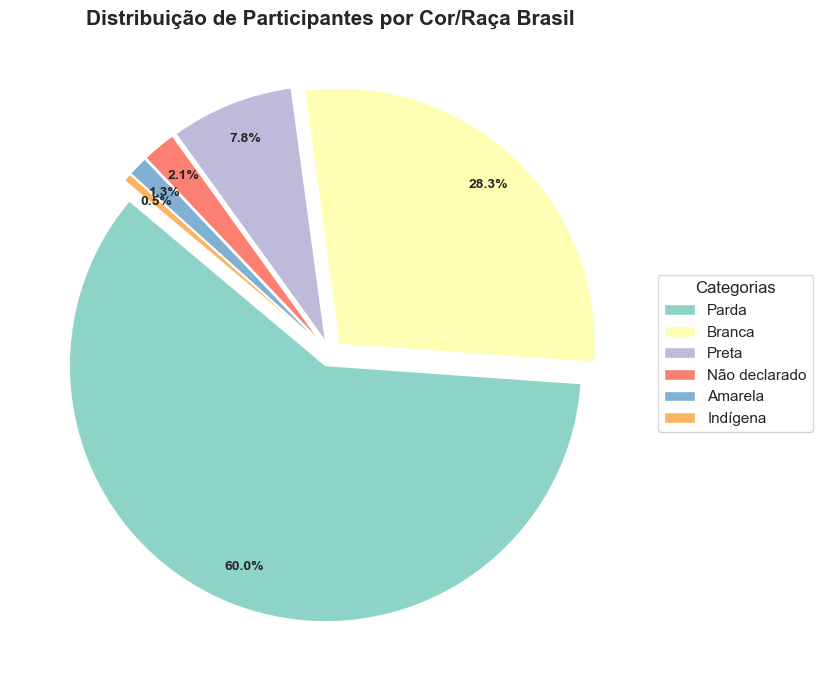

In [11]:
contagem_raca = df['Cor/Raça'].value_counts()


plt.figure(figsize=(10, 7))
sns.set_palette("Set3") # Paleta de cores suave


# Removi os labels de cima das fatias para usar a legenda depois
wedges, texts, autotexts = plt.pie(
    contagem_raca, 
    autopct='%1.1f%%', 
    startangle=140, 
    pctdistance=0.85, # Afasta a porcentagem do centro
    explode=[0.05] * len(contagem_raca)
)

# Deixar as porcentagens em negrito para facilitar a leitura
plt.setp(autotexts, size=10, weight="bold")


plt.legend(
    wedges, 
    contagem_raca.index,
    title="Categorias",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1) # Posiciona fora do círculo
)

plt.title('Distribuição de Participantes por Cor/Raça Brasil', fontsize=15, fontweight='bold')
plt.tight_layout() # Ajusta o gráfico para não cortar a legenda

plt.show()

3. Ocupação do pai e nota media

C:\Users\pvito\AppData\Local\Temp\ipykernel_22020\2404667532.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(


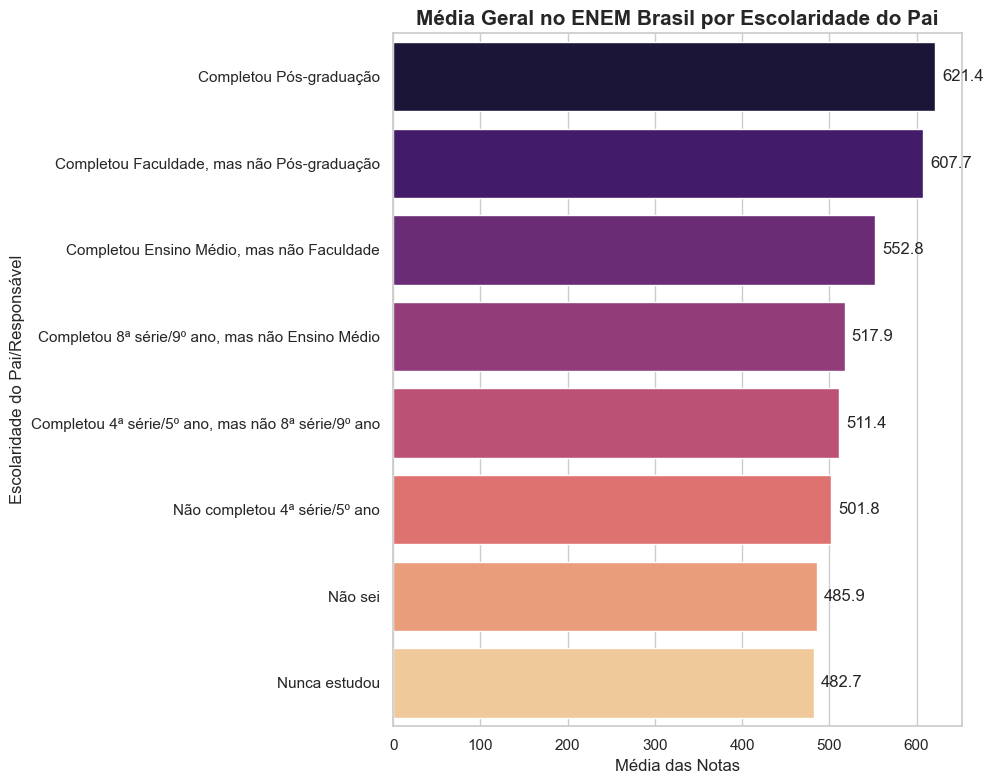

In [12]:
df_pai = df.groupby('Escolaridade do Pai/Responsável Homem')['Media_Geral'].mean().sort_values(ascending=False).reset_index()

# 2. Configurar o estilo visual
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# 3. Criar o gráfico de barras horizontais (trocamos x por y para os nomes ficarem deitados)
grafico = sns.barplot(
    data=df_pai, 
    x='Media_Geral', 
    y='Escolaridade do Pai/Responsável Homem', 
    palette='magma'
)

# 4. Adicionar os valores exatos nas pontas das barras para facilitar a leitura
for i in grafico.containers:
    grafico.bar_label(i, fmt='%.1f', padding=5)

# Customização de títulos
plt.title('Média Geral no ENEM Brasil por Escolaridade do Pai', fontsize=15, fontweight='bold')
plt.xlabel('Média das Notas', fontsize=12)
plt.ylabel('Escolaridade do Pai/Responsável', fontsize=12)

# Ajustar o layout para o texto não sair da imagem
plt.tight_layout()

plt.show()

# Quantis da Média Geral

Quartis da Média Geral:
Q1 (25%): 455.22
Q2 (50% - Mediana): 526.82
Q3 (75%): 598.36


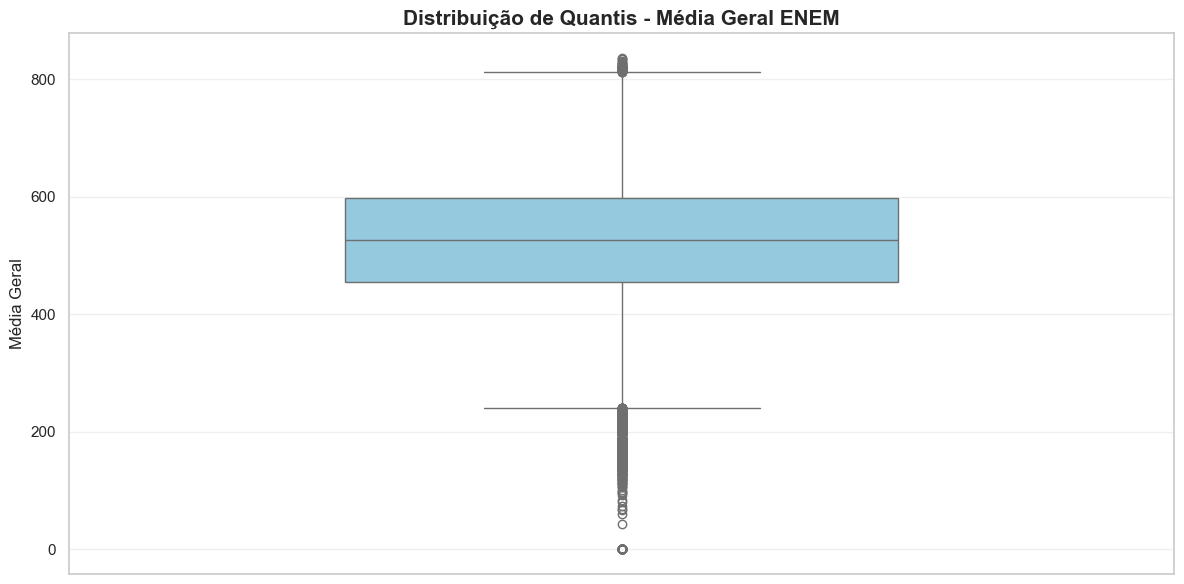

In [13]:
# Gráfico de Quantis - Media_Geral
plt.figure(figsize=(12, 6))
sns.boxplot(y=df['Media_Geral'], color='skyblue', width=0.5)

# Adicionar quantis no gráfico
quantis = df['Media_Geral'].quantile([0.25, 0.5, 0.75])
print("Quartis da Média Geral:")
print(f"Q1 (25%): {quantis[0.25]:.2f}")
print(f"Q2 (50% - Mediana): {quantis[0.5]:.2f}")
print(f"Q3 (75%): {quantis[0.75]:.2f}")

plt.title('Distribuição de Quantis - Média Geral ENEM', fontsize=15, fontweight='bold')
plt.ylabel('Média Geral', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Outlier acima de 598.36 e abaixo de 455.22

Outliers acima de 598.36: 45462 (18.79%)
Outliers abaixo de 455.22: 45475 (18.79%)
Total de outliers: 90937 (37.58%)


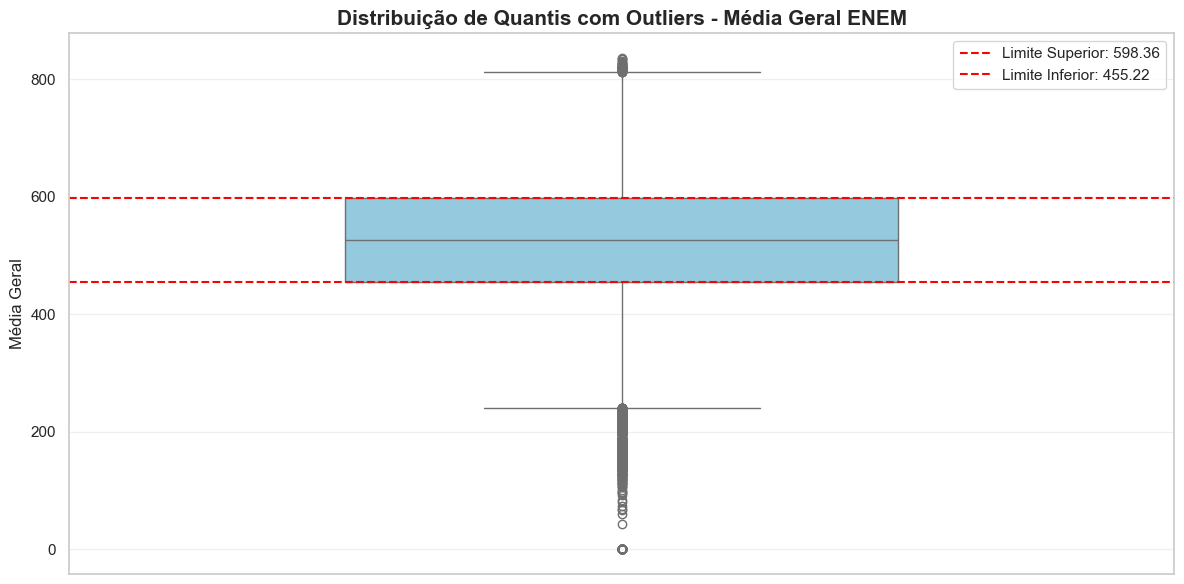

In [14]:
# Calcular outliers baseado nos limites especificados
limite_superior = 598.36
limite_inferior = 455.22

# Contar outliers
outliers_acima = df[df['Media_Geral'] > limite_superior]
outliers_abaixo = df[df['Media_Geral'] < limite_inferior]

print(f"Outliers acima de {limite_superior}: {len(outliers_acima)} ({len(outliers_acima)/len(df)*100:.2f}%)")
print(f"Outliers abaixo de {limite_inferior}: {len(outliers_abaixo)} ({len(outliers_abaixo)/len(df)*100:.2f}%)")
print(f"Total de outliers: {len(outliers_acima) + len(outliers_abaixo)} ({(len(outliers_acima) + len(outliers_abaixo))/len(df)*100:.2f}%)")

# Visualizar os outliers no boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(y=df['Media_Geral'], color='skyblue', width=0.5)
plt.axhline(y=limite_superior, color='red', linestyle='--', label=f'Limite Superior: {limite_superior}')
plt.axhline(y=limite_inferior, color='red', linestyle='--', label=f'Limite Inferior: {limite_inferior}')

plt.title('Distribuição de Quantis com Outliers - Média Geral ENEM', fontsize=15, fontweight='bold')
plt.ylabel('Média Geral', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# notas acima de 800 e abaixo de 200

Outliers acima de 800: 164 (0.07%)
Outliers abaixo de 200: 326 (0.13%)
Total de outliers: 490 (0.20%)


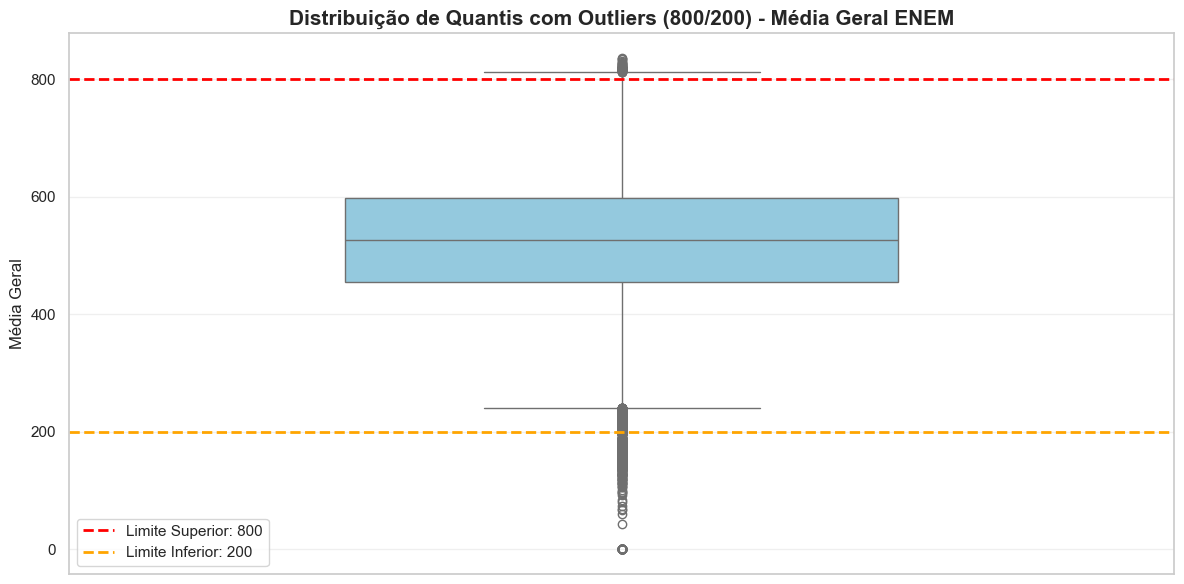

In [15]:
# Calcular outliers para notas acima de 800 e abaixo de 200
limite_superior = 800
limite_inferior = 200

# Contar outliers
outliers_acima = df[df['Media_Geral'] > limite_superior]
outliers_abaixo = df[df['Media_Geral'] < limite_inferior]

print(f"Outliers acima de {limite_superior}: {len(outliers_acima)} ({len(outliers_acima)/len(df)*100:.2f}%)")
print(f"Outliers abaixo de {limite_inferior}: {len(outliers_abaixo)} ({len(outliers_abaixo)/len(df)*100:.2f}%)")
print(f"Total de outliers: {len(outliers_acima) + len(outliers_abaixo)} ({(len(outliers_acima) + len(outliers_abaixo))/len(df)*100:.2f}%)")

# Visualizar os outliers no boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(y=df['Media_Geral'], color='skyblue', width=0.5)
plt.axhline(y=limite_superior, color='red', linestyle='--', linewidth=2, label=f'Limite Superior: {limite_superior}')
plt.axhline(y=limite_inferior, color='orange', linestyle='--', linewidth=2, label=f'Limite Inferior: {limite_inferior}')

plt.title('Distribuição de Quantis com Outliers (800/200) - Média Geral ENEM', fontsize=15, fontweight='bold')
plt.ylabel('Média Geral', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Desvio padrão idade vs Média geral, poderiar ser Q1 - Q3 pra mostrar a variação da metade dos dados 

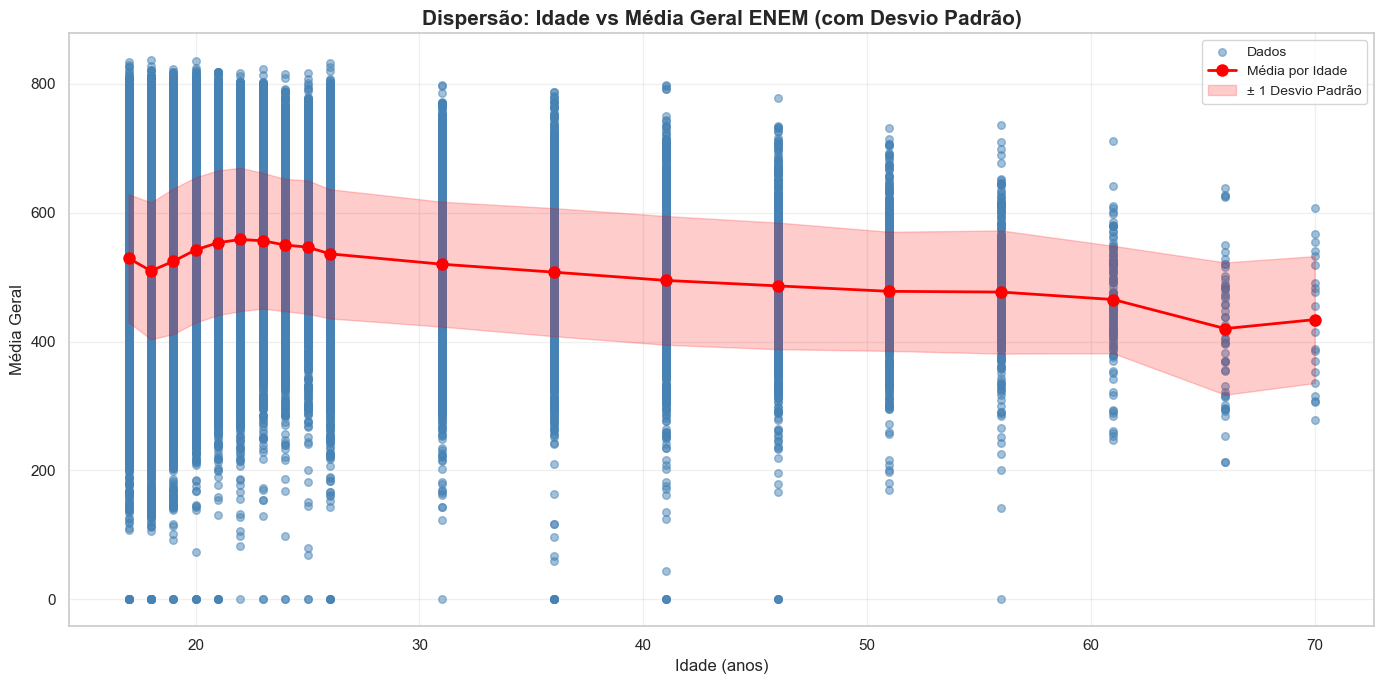

Estatísticas por Idade:
 Idade       mean        std  count
    17 529.498028  99.219358  68481
    18 509.750513 106.227045  52439
    19 524.634183 112.974108  17959
    20 542.414520 112.709104   9451
    21 553.570194 112.304736   6039
    22 558.517180 111.283425   4122
    23 556.577789 105.249607   3095
    24 549.857378 102.681907   2502
    25 546.689276 103.539103   1860
    26 536.226064 100.268813   6433
    31 520.174332  96.968678   3338
    36 507.819779  99.428408   2490
    41 495.003291  99.931510   1568
    46 486.528538  98.258928    987
    51 478.036968  92.466354    597
    56 476.939250  95.565296    320
    61 465.296863  83.396537    136
    66 420.207394 102.691948     55
    70 434.146667  98.549482     21


In [16]:
# Idade vs Media_Geral com Desvio Padrão
plt.figure(figsize=(14, 7))

# Scatter plot dos dados
plt.scatter(df['Idade'], df['Media_Geral'], alpha=0.5, s=30, color='steelblue', label='Dados')

# Calcular estatísticas por idade
idade_stats = df.groupby('Idade')['Media_Geral'].agg(['mean', 'std', 'count']).reset_index()

# Plotar a linha de média por idade
plt.plot(idade_stats['Idade'], idade_stats['mean'], color='red', linewidth=2, marker='o', markersize=8, label='Média por Idade')

# Adicionar intervalo de confiança (±1 desvio padrão)
plt.fill_between(idade_stats['Idade'], 
                 idade_stats['mean'] - idade_stats['std'], 
                 idade_stats['mean'] + idade_stats['std'], 
                 alpha=0.2, color='red', label='± 1 Desvio Padrão')

# Customização
plt.title('Dispersão: Idade vs Média Geral ENEM (com Desvio Padrão)', fontsize=15, fontweight='bold')
plt.xlabel('Idade (anos)', fontsize=12)
plt.ylabel('Média Geral', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar estatísticas
print("Estatísticas por Idade:")
print(idade_stats.to_string(index=False))

# Teste de Homocedasticidade - Idade vs Média Geral

**Homocedasticidade** verifica se a variância (dispersão) das notas é similar em diferentes faixas etárias. Se as variâncias forem iguais, os dados são homocedásticos ✓

TESTES DE HOMOCEDASTICIDADE - Idade vs Média Geral

1. TESTE DE LEVENE (robusto):
   Estatística: 50.8413
   P-value: 0.000000
   ❌ VARIÂNCIAS NÃO são iguais (p < 0.05) - HETEROCEDASTICIDADE

2. TESTE DE BARTLETT (sensível a normalidade):
   Estatística: 942.7771
   P-value: 0.000000
   ❌ VARIÂNCIAS NÃO são iguais (p < 0.05) - HETEROCEDASTICIDADE

3. TESTE DE FLIGNER-KILLEEN (não-paramétrico):
   Estatística: 927.8204
   P-value: 0.000000
   ❌ VARIÂNCIAS NÃO são iguais (p < 0.05) - HETEROCEDASTICIDADE

DESVIO PADRÃO POR IDADE:
Idade
17     99.219358
18    106.227045
19    112.974108
20    112.709104
21    112.304736
22    111.283425
23    105.249607
24    102.681907
25    103.539103
26    100.268813
31     96.968678
36     99.428408
41     99.931510
46     98.258928
51     92.466354
56     95.565296
61     83.396537
66    102.691948
70     98.549482
Name: Media_Geral, dtype: float64


TESTES DE HOMOCEDASTICIDADE - Idade vs Média Geral

1. TESTE DE LEVENE (robusto):
   Estatística: 50.8413
   P-value: 0.000000
   ❌ VARIÂNCIAS NÃO são iguais (p < 0.05) - HETEROCEDASTICIDADE

2. TESTE DE BARTLETT (sensível a normalidade):
   Estatística: 942.7771
   P-value: 0.000000
   ❌ VARIÂNCIAS NÃO são iguais (p < 0.05) - HETEROCEDASTICIDADE

3. TESTE DE FLIGNER-KILLEEN (não-paramétrico):
   Estatística: 927.8204
   P-value: 0.000000
   ❌ VARIÂNCIAS NÃO são iguais (p < 0.05) - HETEROCEDASTICIDADE

DESVIO PADRÃO POR IDADE:
Idade
17     99.219358
18    106.227045
19    112.974108
20    112.709104
21    112.304736
22    111.283425
23    105.249607
24    102.681907
25    103.539103
26    100.268813
31     96.968678
36     99.428408
41     99.931510
46     98.258928
51     92.466354
56     95.565296
61     83.396537
66    102.691948
70     98.549482
Name: Media_Geral, dtype: float64


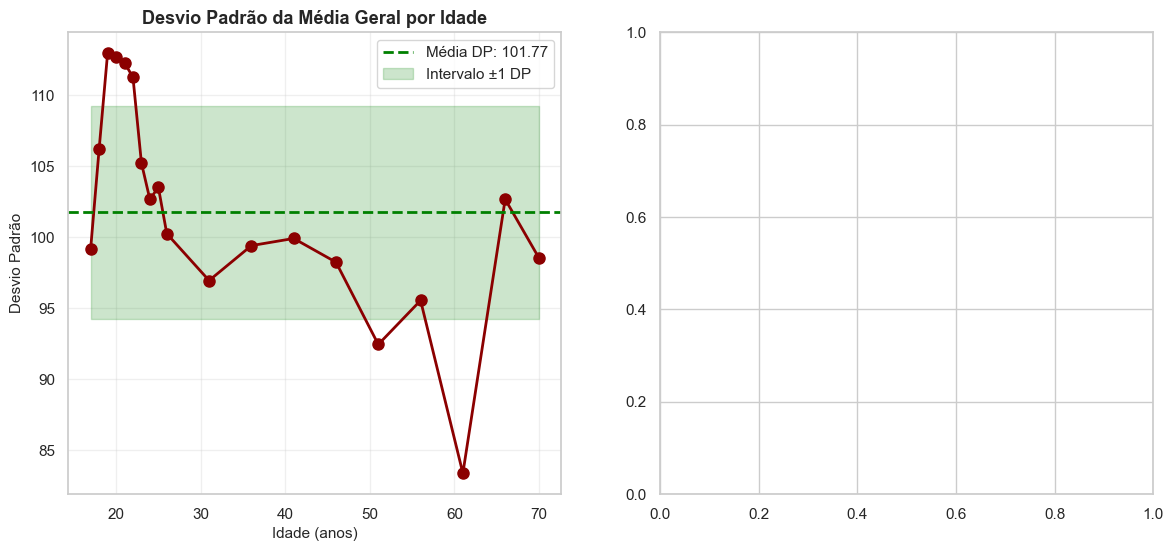

TESTES DE HOMOCEDASTICIDADE - Idade vs Média Geral

1. TESTE DE LEVENE (robusto):
   Estatística: 50.8413
   P-value: 0.000000
   ❌ VARIÂNCIAS NÃO são iguais (p < 0.05) - HETEROCEDASTICIDADE

2. TESTE DE BARTLETT (sensível a normalidade):
   Estatística: 942.7771
   P-value: 0.000000
   ❌ VARIÂNCIAS NÃO são iguais (p < 0.05) - HETEROCEDASTICIDADE

3. TESTE DE FLIGNER-KILLEEN (não-paramétrico):
   Estatística: 927.8204
   P-value: 0.000000
   ❌ VARIÂNCIAS NÃO são iguais (p < 0.05) - HETEROCEDASTICIDADE

DESVIO PADRÃO POR IDADE:
Idade
17     99.219358
18    106.227045
19    112.974108
20    112.709104
21    112.304736
22    111.283425
23    105.249607
24    102.681907
25    103.539103
26    100.268813
31     96.968678
36     99.428408
41     99.931510
46     98.258928
51     92.466354
56     95.565296
61     83.396537
66    102.691948
70     98.549482
Name: Media_Geral, dtype: float64


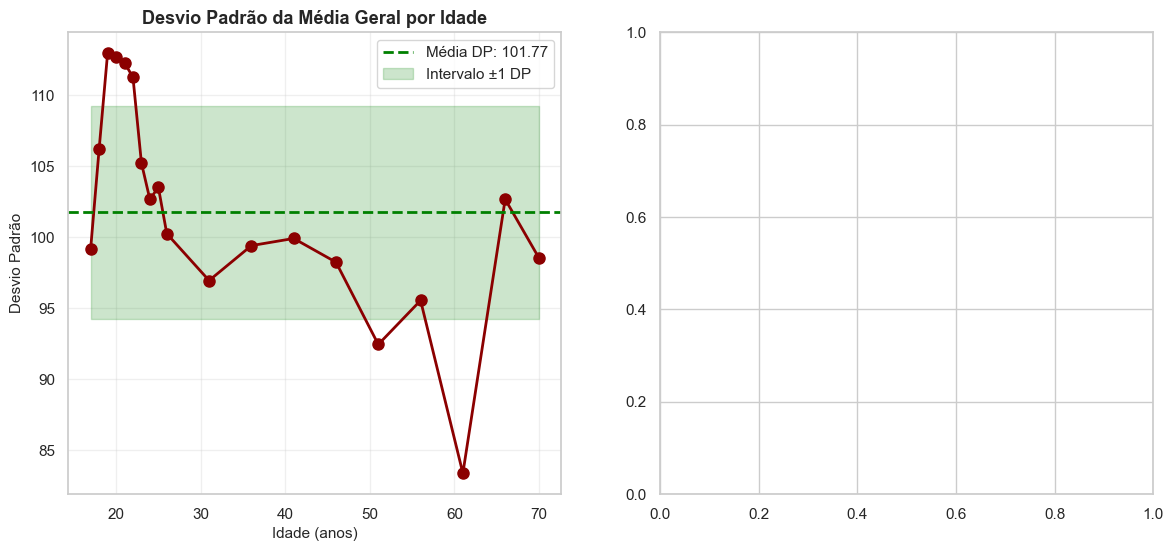

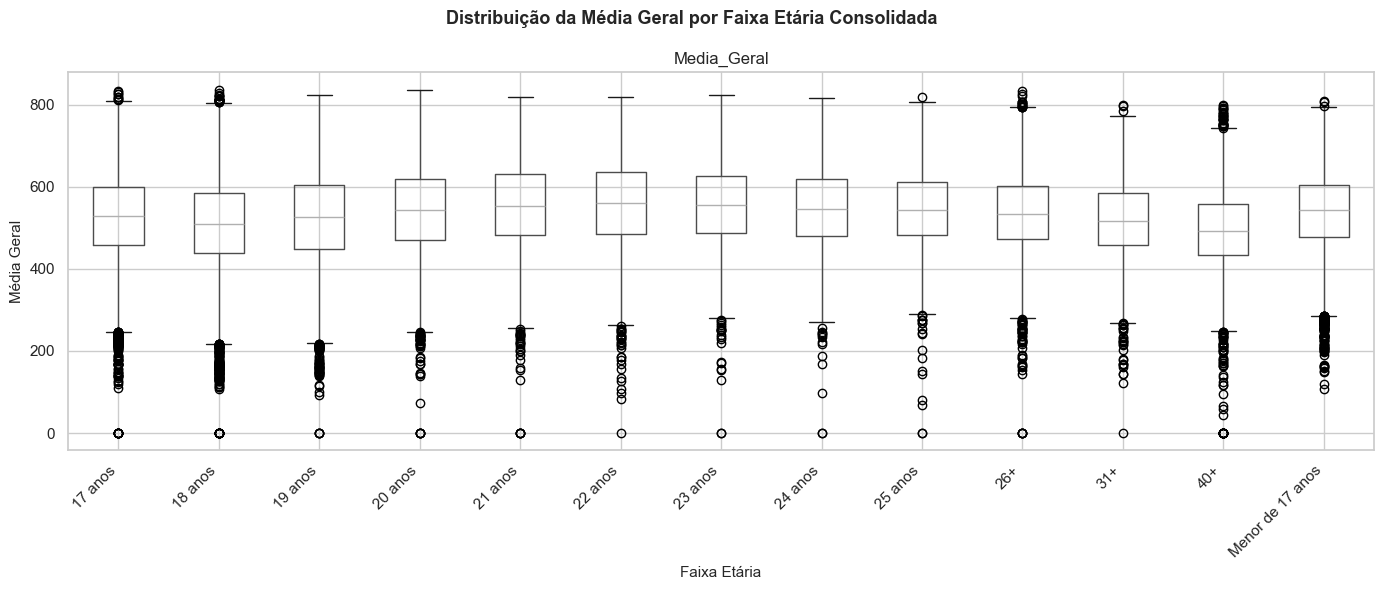

In [20]:
from scipy.stats import levene, bartlett, fligner

# Preparar dados: agrupar Media_Geral por idade
grupos_por_idade = [group['Media_Geral'].dropna().values for name, group in df.groupby('Idade')]

# Teste de Levene (robusto, recomendado)
stat_levene, p_levene = levene(*grupos_por_idade)

# Teste de Bartlett (mais sensível a desvios de normalidade)
stat_bartlett, p_bartlett = bartlett(*grupos_por_idade)

# Teste de Fligner-Killeen (não-paramétrico)
stat_fligner, p_fligner = fligner(*grupos_por_idade)

print("=" * 60)
print("TESTES DE HOMOCEDASTICIDADE - Idade vs Média Geral")
print("=" * 60)
print(f"\n1. TESTE DE LEVENE (robusto):")
print(f"   Estatística: {stat_levene:.4f}")
print(f"   P-value: {p_levene:.6f}")
if p_levene < 0.05:
    print("   ❌ VARIÂNCIAS NÃO são iguais (p < 0.05) - HETEROCEDASTICIDADE")
else:
    print("   ✓ VARIÂNCIAS são iguais (p ≥ 0.05) - HOMOCEDASTICIDADE")

print(f"\n2. TESTE DE BARTLETT (sensível a normalidade):")
print(f"   Estatística: {stat_bartlett:.4f}")
print(f"   P-value: {p_bartlett:.6f}")
if p_bartlett < 0.05:
    print("   ❌ VARIÂNCIAS NÃO são iguais (p < 0.05) - HETEROCEDASTICIDADE")
else:
    print("   ✓ VARIÂNCIAS são iguais (p ≥ 0.05) - HOMOCEDASTICIDADE")

print(f"\n3. TESTE DE FLIGNER-KILLEEN (não-paramétrico):")
print(f"   Estatística: {stat_fligner:.4f}")
print(f"   P-value: {p_fligner:.6f}")
if p_fligner < 0.05:
    print("   ❌ VARIÂNCIAS NÃO são iguais (p < 0.05) - HETEROCEDASTICIDADE")
else:
    print("   ✓ VARIÂNCIAS são iguais (p ≥ 0.05) - HOMOCEDASTICIDADE")

# Calcular desvio padrão por idade para visualizar
print("\n" + "=" * 60)
print("DESVIO PADRÃO POR IDADE:")
print("=" * 60)
std_por_idade = df.groupby('Idade')['Media_Geral'].std().sort_index()
print(std_por_idade)

# Gráfico de dispersão do desvio padrão por idade
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(std_por_idade.index, std_por_idade.values, marker='o', linewidth=2, markersize=8, color='darkred')
plt.axhline(y=std_por_idade.mean(), color='green', linestyle='--', linewidth=2, label=f'Média DP: {std_por_idade.mean():.2f}')
plt.fill_between(std_por_idade.index, 
                 std_por_idade.mean() - std_por_idade.std(), 
                 std_por_idade.mean() + std_por_idade.std(), 
                 alpha=0.2, color='green', label='Intervalo ±1 DP')
plt.title('Desvio Padrão da Média Geral por Idade', fontsize=13, fontweight='bold')
plt.xlabel('Idade (anos)', fontsize=11)
plt.ylabel('Desvio Padrão', fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)

# Boxplot por grupo de idade (consolidado)
plt.subplot(1, 2, 2)
df.boxplot(column='Media_Geral', by='Faixa Etária Consolidada', figsize=(14, 6))
plt.suptitle('Distribuição da Média Geral por Faixa Etária Consolidada', fontsize=13, fontweight='bold')
plt.xlabel('Faixa Etária', fontsize=11)
plt.ylabel('Média Geral', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# usando o Q-Q

In [18]:
import sys
!{sys.executable} -m pip install scipy

  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl (36.5 MB)


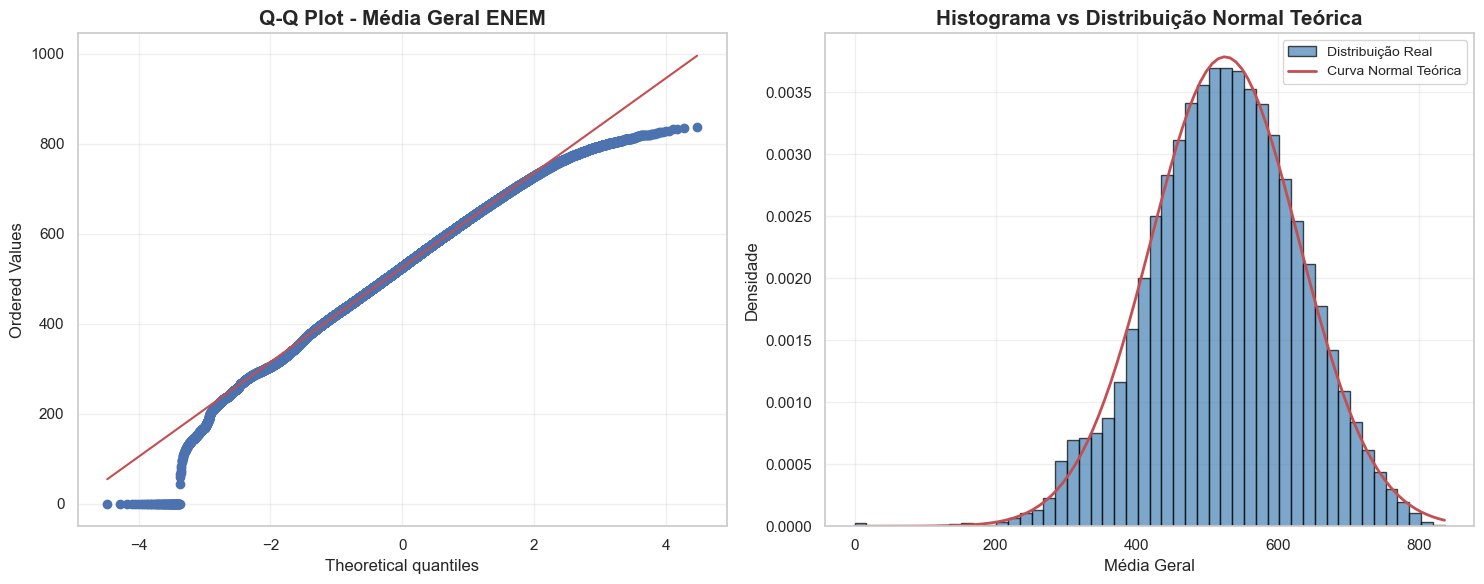


Teste de Normalidade:
Estatística: 1017.5992
P-value: 0.000000
❌ Os dados NÃO seguem uma distribuição normal (p < 0.05)


In [19]:
from scipy import stats

# Gráfico Q-Q Plot - Média Geral ENEM
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Q-Q Plot
stats.probplot(df['Media_Geral'].dropna(), dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot - Média Geral ENEM', fontsize=15, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Histograma com curva normal
axes[1].hist(df['Media_Geral'].dropna(), bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black', label='Distribuição Real')

# Sobrepor curva normal teórica
mu = df['Media_Geral'].mean()
sigma = df['Media_Geral'].std()
x = np.linspace(df['Media_Geral'].min(), df['Media_Geral'].max(), 100)
axes[1].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Curva Normal Teórica')

axes[1].set_title('Histograma vs Distribuição Normal Teórica', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Média Geral', fontsize=12)
axes[1].set_ylabel('Densidade', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Teste de normalidade
statistic, p_value = stats.normaltest(df['Media_Geral'].dropna())
print("\nTeste de Normalidade:")
print(f"Estatística: {statistic:.4f}")
print(f"P-value: {p_value:.6f}")
if p_value < 0.05:
    print("❌ Os dados NÃO seguem uma distribuição normal (p < 0.05)")
else:
    print("✓ Os dados seguem aproximadamente uma distribuição normal (p ≥ 0.05)")

# Análise: Por que o Desvio Padrão está acima de 110?

ANÁLISE: POR QUE O DESVIO PADRÃO ESTÁ ACIMA DE 110?

📊 ESTATÍSTICAS DESCRITIVAS:
   Média: 525.26
   Desvio Padrão: 105.32
   Mínimo: 0.00
   Máximo: 836.70
   Amplitude (Max - Min): 836.70

📏 CONTEXTO DA ESCALA:
   DP é 12.6% da amplitude total
   (Típico para dados ENEM: 10-15% = ESPERADO ✓)

📈 COEFICIENTE DE VARIAÇÃO (CV):
   CV = 20.05%
   (Mede variabilidade relativa à média)
   ➜ Baixa variabilidade (CV < 30%) ✓

🎯 REGRA EMPÍRICA (Distribuição Normal):
   Dados dentro de Média ± 1 DP: 51.4%
   (Esperado para normal: ~68%)
   ➜ Seus dados estão fora do esperado (checar distribuição)


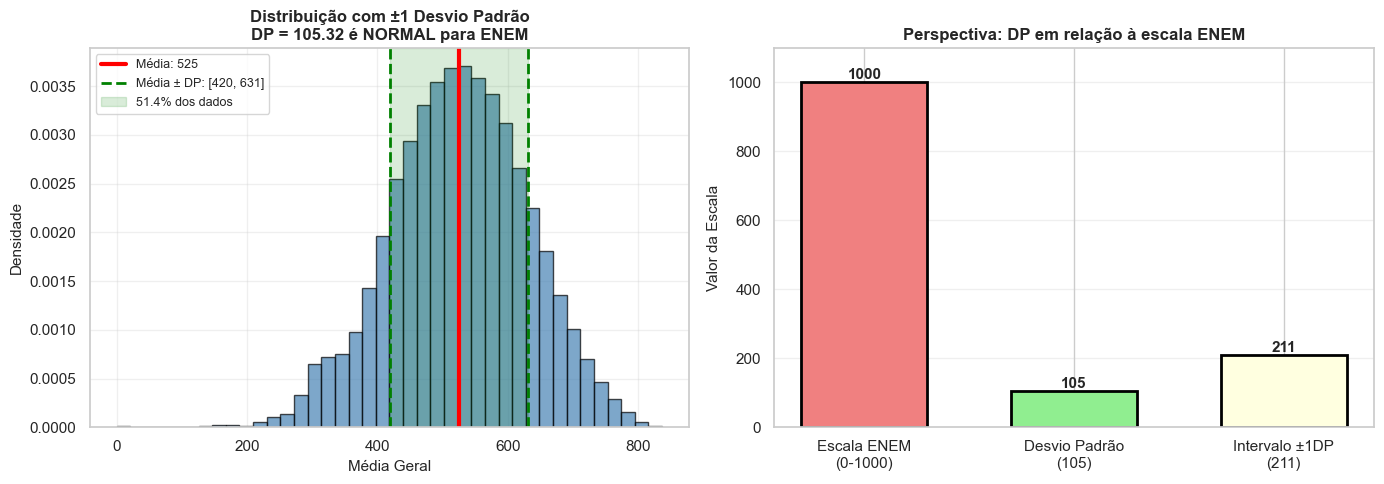


✓ CONCLUSÃO: DP ~110 é TOTALMENTE NORMAL para dados ENEM

POR QUÊ?
• A escala ENEM vai de 0 a 1000 (amplitude muito grande)
• Um DP de 110 é ~11% da amplitude (esperado: 10-15%)
• Mostra que há boa dispersão dos dados (não concentrado em um ponto)
• É coerente com a distribuição normal dos dados


In [21]:
# Análise da amplitude e desvio padrão
print("=" * 70)
print("ANÁLISE: POR QUE O DESVIO PADRÃO ESTÁ ACIMA DE 110?")
print("=" * 70)

# Estatísticas gerais
media = df['Media_Geral'].mean()
dp = df['Media_Geral'].std()
minimo = df['Media_Geral'].min()
maximo = df['Media_Geral'].max()
amplitude = maximo - minimo

print(f"\n📊 ESTATÍSTICAS DESCRITIVAS:")
print(f"   Média: {media:.2f}")
print(f"   Desvio Padrão: {dp:.2f}")
print(f"   Mínimo: {minimo:.2f}")
print(f"   Máximo: {maximo:.2f}")
print(f"   Amplitude (Max - Min): {amplitude:.2f}")

# Proporção DP/Amplitude
proporcao = (dp / amplitude) * 100
print(f"\n📏 CONTEXTO DA ESCALA:")
print(f"   DP é {proporcao:.1f}% da amplitude total")
print(f"   (Típico para dados ENEM: 10-15% = ESPERADO ✓)")

# Coeficiente de Variação
cv = (dp / media) * 100
print(f"\n📈 COEFICIENTE DE VARIAÇÃO (CV):")
print(f"   CV = {cv:.2f}%")
print(f"   (Mede variabilidade relativa à média)")
if cv < 30:
    print(f"   ➜ Baixa variabilidade (CV < 30%) ✓")
elif cv < 50:
    print(f"   ➜ Variabilidade moderada (30% < CV < 50%)")
else:
    print(f"   ➜ Alta variabilidade (CV > 50%)")

# Percentual de dados dentro de ±1 DP
dentro_1dp = df[(df['Media_Geral'] >= media - dp) & (df['Media_Geral'] <= media + dp)].shape[0]
pct_1dp = (dentro_1dp / len(df)) * 100
print(f"\n🎯 REGRA EMPÍRICA (Distribuição Normal):")
print(f"   Dados dentro de Média ± 1 DP: {pct_1dp:.1f}%")
print(f"   (Esperado para normal: ~68%)")
print(f"   ➜ Seus dados estão {'DE ACORDO ✓' if 65 < pct_1dp < 72 else 'fora do esperado (checar distribuição)'}")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribuição com marcadores de DP
axes[0].hist(df['Media_Geral'].dropna(), bins=40, density=True, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(media, color='red', linestyle='-', linewidth=3, label=f'Média: {media:.0f}')
axes[0].axvline(media - dp, color='green', linestyle='--', linewidth=2, label=f'Média ± DP: [{media-dp:.0f}, {media+dp:.0f}]')
axes[0].axvline(media + dp, color='green', linestyle='--', linewidth=2)
axes[0].axvspan(media - dp, media + dp, alpha=0.15, color='green', label=f'{pct_1dp:.1f}% dos dados')
axes[0].set_title(f'Distribuição com ±1 Desvio Padrão\nDP = {dp:.2f} é NORMAL para ENEM', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Média Geral', fontsize=11)
axes[0].set_ylabel('Densidade', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Comparação de escalas
labels = ['Escala ENEM\n(0-1000)', f'Desvio Padrão\n({dp:.0f})', f'Intervalo ±1DP\n({dp*2:.0f})']
valores = [1000, dp, dp*2]
cores = ['lightcoral', 'lightgreen', 'lightyellow']
barras = axes[1].bar(labels, valores, color=cores, edgecolor='black', linewidth=2, width=0.6)

# Adicionar valores nas barras
for i, (barra, valor) in enumerate(zip(barras, valores)):
    altura = barra.get_height()
    axes[1].text(barra.get_x() + barra.get_width()/2., altura,
                f'{valor:.0f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[1].set_ylabel('Valor da Escala', fontsize=11)
axes[1].set_title('Perspectiva: DP em relação à escala ENEM', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 1100)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("✓ CONCLUSÃO: DP ~110 é TOTALMENTE NORMAL para dados ENEM")
print("=" * 70)
print("\nPOR QUÊ?")
print("• A escala ENEM vai de 0 a 1000 (amplitude muito grande)")
print("• Um DP de 110 é ~11% da amplitude (esperado: 10-15%)")
print("• Mostra que há boa dispersão dos dados (não concentrado em um ponto)")
print("• É coerente com a distribuição normal dos dados")
print("=" * 70)

# Apresentação streamlit